## Data Analytics

### Chapter 15: Distribution, Skewness, and Kurtosis

Understanding how data is distributed is an important part of exploratory data analysis. The distribution of a dataset reveals how values are spread, whether they are concentrated around a central value, and whether unusual patterns or outliers exist. 

By examining data distributions, we can choose appropriate statistical methods, detect anomalies, and better understand the characteristics of a dataset.

#### Generate Synthetic Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [74]:
n = 1000

df = pd.DataFrame({
    "ID": [i for i in range(1, n + 1)],
    "Age": np.random.randint(18, 22, n),
    "Major": np.random.choice(["AI", "CSC", "IT", "SW"], n),
    "GPA": np.round(np.random.uniform(2.0, 4.0, n), 2)
})

df.groupby('Major')['GPA'].agg('mean')

Major
AI     3.016929
CSC    3.001521
IT     2.975019
SW     3.073175
Name: GPA, dtype: float64

#### 15.1. Data Distribution

Different datasets follow different probability distributions.

In [75]:
uniform = np.random.uniform(0, 1, 1000)
normal = np.random.normal(0, 1, 1000)
exponential = np.random.exponential(1, 1000)
binomial = np.random.binomial(10, 0.5, 1000)
poisson = np.random.poisson(5, 1000)
lognormal = np.random.lognormal(0, 0.5, 1000)

In [ ]:
# Helper function to plot distribution
def plot_distribution(dist_type, name):
    plt.figure(figsize=(6,4))
    plt.hist(dist_type, bins=30)
    plt.title(f"{name} Distribution")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

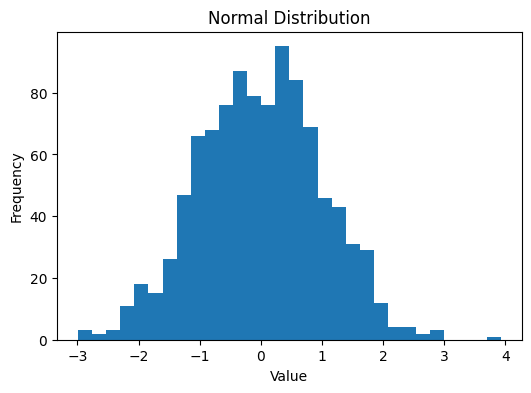

In [77]:
#  a histogram of a normally distributed dataset can be plotted as follows
plot_distribution(normal, "Normal")

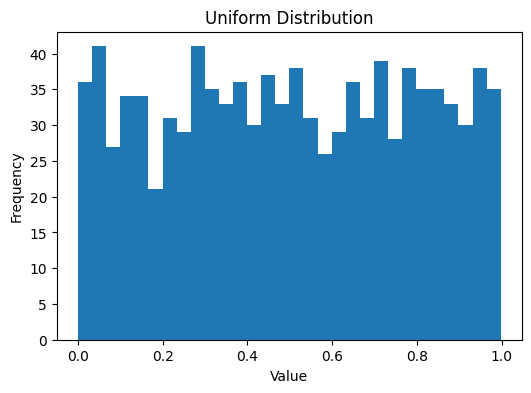

In [78]:
plot_distribution(uniform, "Uniform")

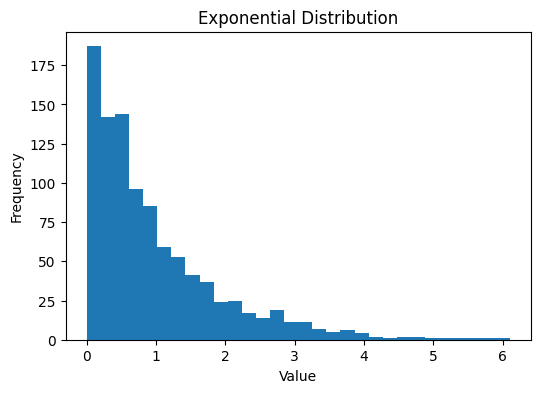

In [79]:
plot_distribution(exponential, "Exponential")

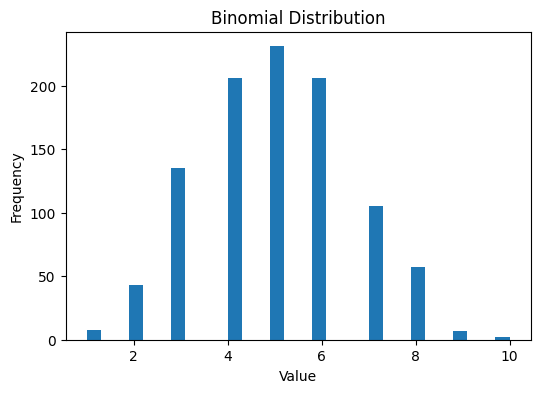

In [80]:
plot_distribution(binomial, "Binomial")

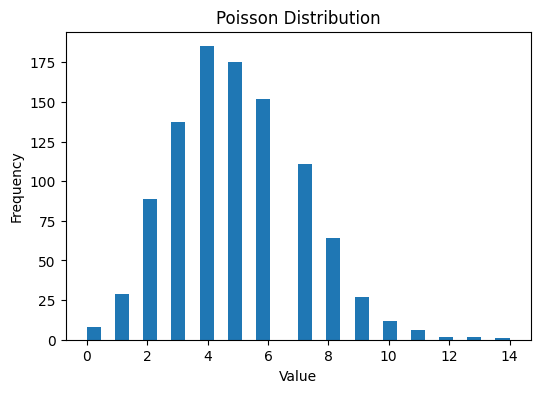

In [81]:
plot_distribution(poisson, "Poisson")

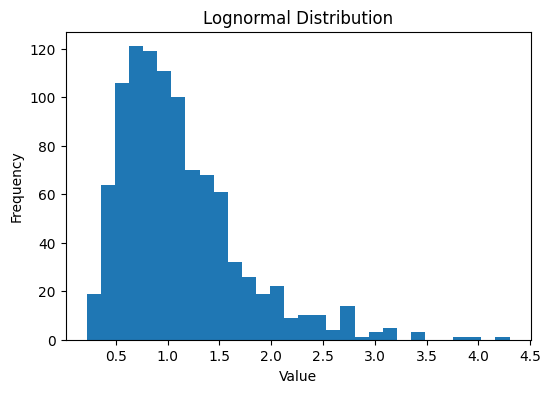

In [82]:
plot_distribution(lognormal, "Lognormal")

#### 15.2. Skewness

**Skewness** measures the asymmetry of a data distribution.

- **Skewness > 0:** Right-skewed distribution with a longer tail on the right.
- **Skewness < 0:** Left-skewed distribution with a longer tail on the left.
- **Skewness ≈ 0:** Approximately symmetric distribution.

In [83]:
print("GPA Skewness:", df["GPA"].skew())

GPA Skewness: -0.05944924607366936


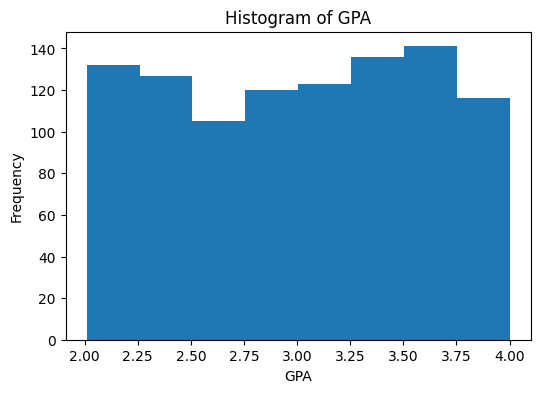

In [84]:
# To visualize the distribution, plot a histogram.
plt.figure(figsize=(6,4))
plt.hist(df["GPA"], bins=8)
plt.title("Histogram of GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

In [85]:
# A simple interpretation can be performed automatically.
skew = df["GPA"].skew()

if skew > 0.5:
    print("The distribution is positively (right) skewed.")
elif skew < -0.5:
    print("The distribution is negatively (left) skewed.")
else:
    print("The distribution is approximately symmetric.")

The distribution is approximately symmetric.


Use the Beta distribution, since it naturally produces left- and right-skewed data. We can then scale the values to the GPA range of 2.0–4.0.

In [87]:
# Shared columns
ids = np.arange(1, n + 1)
ages = np.random.randint(18, 22, n)
majors = np.random.choice(["AI", "CSC", "IT", "SW"], n)

# Right-skewed GPA (most students have lower GPA)
gpa_right = 2 + np.random.beta(2, 5, n) * 2

# Left-skewed GPA (most students have higher GPA)
gpa_left = 2 + np.random.beta(5, 2, n) * 2

df_right = pd.DataFrame({
    "ID": ids,
    "Age": ages,
    "Major": majors,
    "GPA": np.round(gpa_right, 2)
})

df_left = pd.DataFrame({
    "ID": ids,
    "Age": ages,
    "Major": majors,
    "GPA": np.round(gpa_left, 2)
})

In [88]:
# verify the skewness
print("Right-skewed GPA:", df_right["GPA"].skew())
print("Left-skewed GPA :", df_left["GPA"].skew())

Right-skewed GPA: 0.583320213373598
Left-skewed GPA : -0.6249211274173291


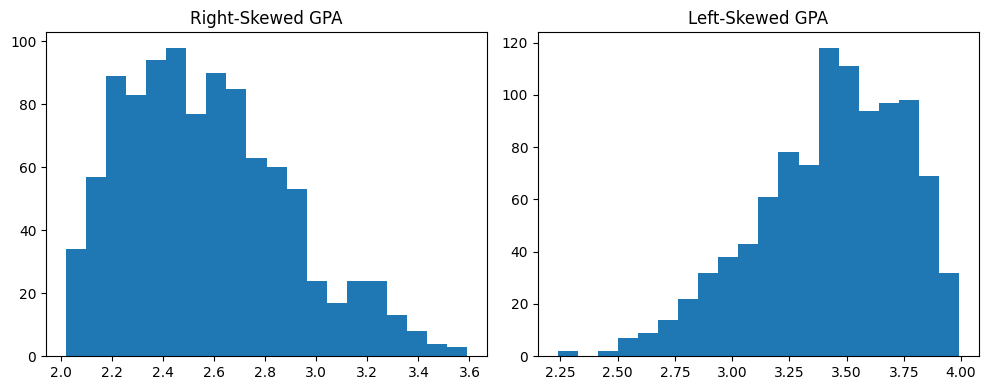

In [89]:
# compare them visually
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df_right["GPA"], bins=20)
plt.title("Right-Skewed GPA")

plt.subplot(1,2,2)
plt.hist(df_left["GPA"], bins=20)
plt.title("Left-Skewed GPA")

plt.tight_layout()
plt.show()

#### 15.3. Kurtosis

Kurtosis measures the heaviness of a distribution's tails and the sharpness of its peak.

- **Kurtosis > 3:** Sharp peak with heavier tails (more extreme values).
- **Kurtosis < 3:** Flatter distribution with lighter tails.
- **Kurtosis ≈ 3:** Similar to a normal distribution.

In [90]:
print("Excess Kurtosis:", df["GPA"].kurt())

Excess Kurtosis: -1.2174230585636967


Generate three datasets:

- Mesokurtic (Normal kurtosis): similar to a normal distribution (excess kurtosis ≈ 0)

- Leptokurtic: sharp peak with heavy tails (positive excess kurtosis)

- Platykurtic: flatter peak with light tails (negative excess kurtosis)

In [91]:
kurt = df["GPA"].kurt()

if kurt > 0:
    print("The distribution has heavier tails than a normal distribution.")
elif kurt < 0:
    print("The distribution has lighter tails than a normal distribution.")
else:
    print("The distribution is similar to a normal distribution.")

The distribution has lighter tails than a normal distribution.


In [92]:
n = 1000

# Normal (Mesokurtic)
gpa_normal = np.random.normal(3.0, 0.35, n)

# Leptokurtic (Heavy tails)
gpa_lepto = np.random.standard_t(df=3, size=n)
gpa_lepto = 3 + gpa_lepto * 0.20

# Platykurtic (Light tails)
gpa_platy = np.random.uniform(2.0, 4.0, n)

# Keep GPAs within [2.0, 4.0]
gpa_normal = np.clip(gpa_normal, 2.0, 4.0)
gpa_lepto = np.clip(gpa_lepto, 2.0, 4.0)

df_normal = pd.DataFrame({"GPA": np.round(gpa_normal, 2)})
df_lepto = pd.DataFrame({"GPA": np.round(gpa_lepto, 2)})
df_platy = pd.DataFrame({"GPA": np.round(gpa_platy, 2)})

In [ ]:
# Verify the kurtosis
print("Normal      :", df_normal["GPA"].kurt())
print("Leptokurtic :", df_lepto["GPA"].kurt())
print("Platykurtic :", df_platy["GPA"].kurt())

Normal      : -0.06220907127728559
Leptokurtic : 1.6968286510271056
Platykurtic : -1.1447958686148985


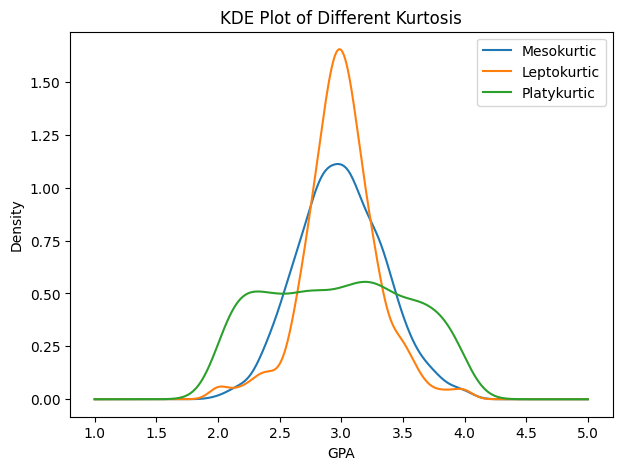

In [94]:
# KDE Plot Comparison
plt.figure(figsize=(7,5))

df_normal["GPA"].plot(kind="kde", label="Mesokurtic")
df_lepto["GPA"].plot(kind="kde", label="Leptokurtic")
df_platy["GPA"].plot(kind="kde", label="Platykurtic")

plt.title("KDE Plot of Different Kurtosis")
plt.xlabel("GPA")
plt.ylabel("Density")
plt.legend()
plt.show()